# 05 — Comparação de Resultados e Apresentação
**TCC PUC — Ciência de Dados e Big Data**
Evandro Ribeiro Gomes Coelho

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

PROC = '../data/processed/'
print('Setup OK')

Setup OK


In [2]:
# ── Carrega resultados dos notebooks anteriores ───────────────────────────────
results_baseline = pd.read_csv(PROC + 'results_baseline.csv')
results_advanced = pd.read_csv(PROC + 'results_advanced.csv')
preds_df = pd.read_csv(PROC + 'predictions.csv', parse_dates=['Timestamp'])

# Unifica todos os resultados
all_results = pd.concat([results_baseline, results_advanced], ignore_index=True)
all_results = all_results.sort_values('R²', ascending=False).reset_index(drop=True)

print('Resultados carregados:')
display(all_results)

Resultados carregados:


,Modelo,MAE,RMSE,R²,MAPE (%)
0,MLP (features expandidas),3.3644,17.4877,0.99996,0.099
1,Random Forest,37.4732,74.5665,0.99928,0.988
2,XGBoost,95.8274,128.1559,0.99786,2.606
3,LSTM,104.2571,143.1564,0.99733,3.715
4,Regressão Linear,1083.8078,1499.3586,0.70716,27.487
5,MME (α=0.5),1197.6700,1709.2959,0.61941,29.263
6,MME (α=0.3),1296.0484,1802.9547,0.57656,33.667
7,MME (α=0.1),1519.6861,1996.9895,0.48051,45.349
8,MMS (w=12),1492.1786,2020.4274,0.46825,41.823
9,MMS (w=6),1477.4809,2026.9756,0.46479,38.345


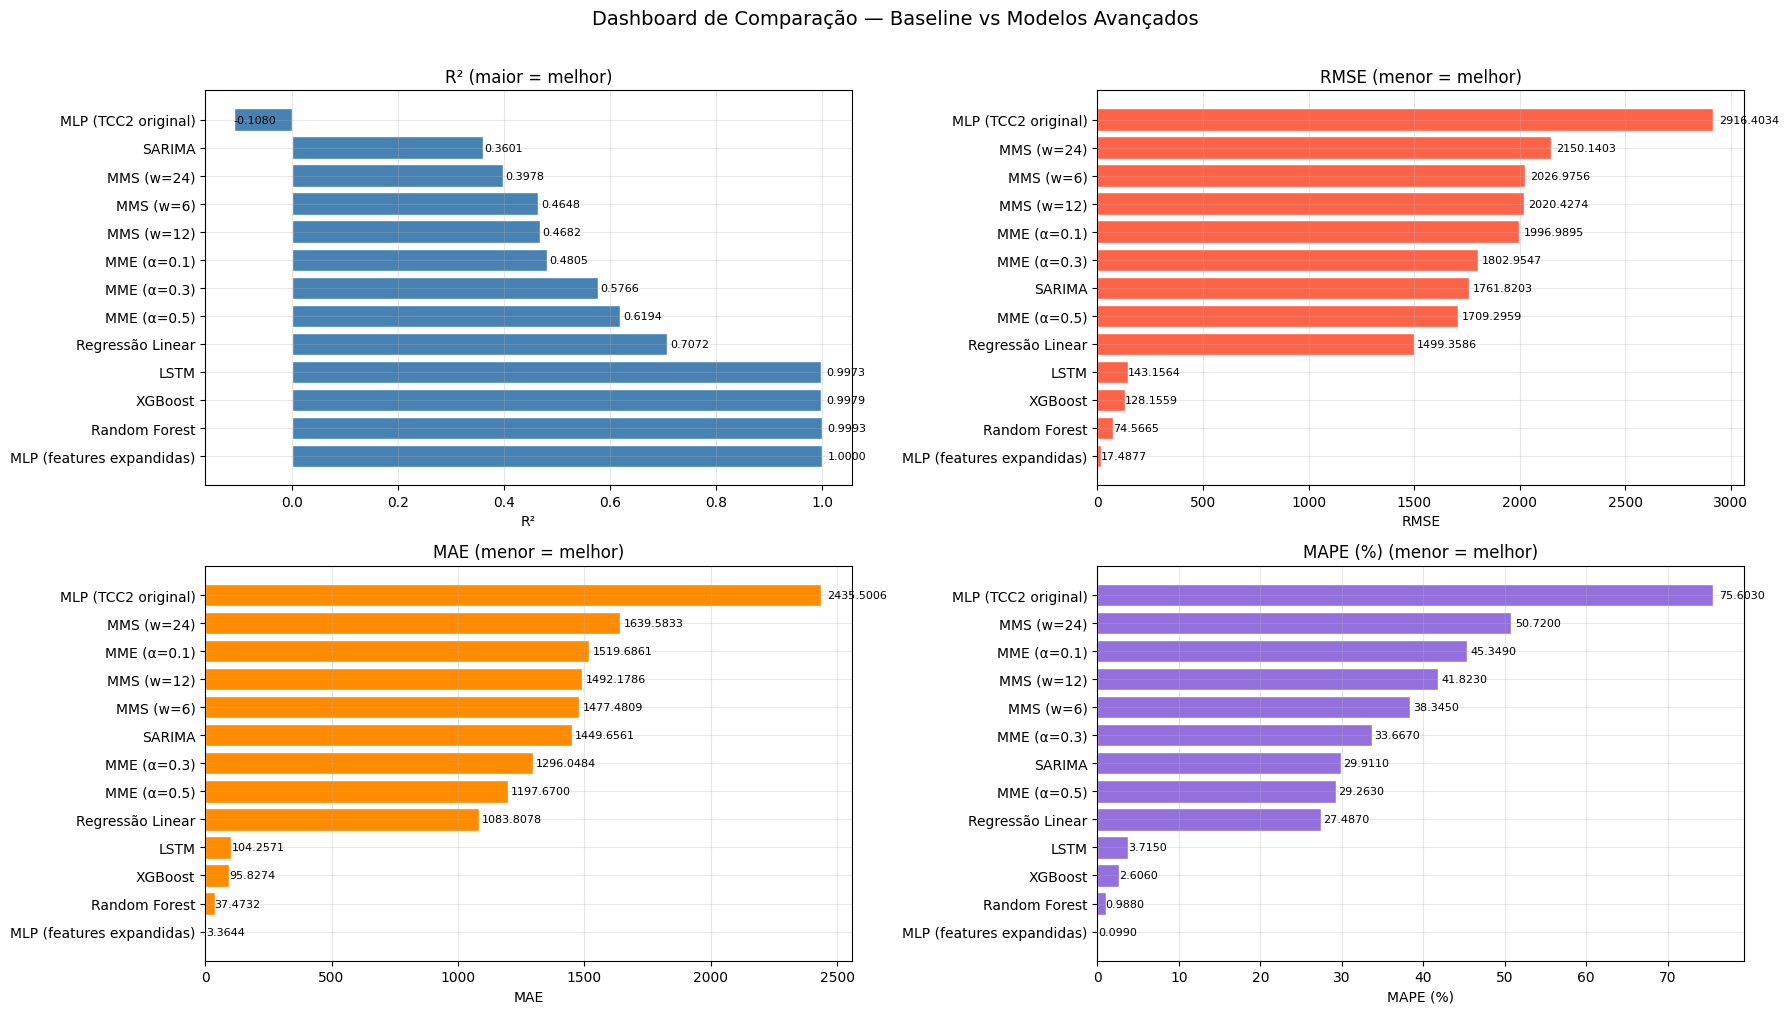

In [3]:
metrics = ['R²', 'RMSE', 'MAE', 'MAPE (%)']
ascending_map = {'R²': False, 'RMSE': True, 'MAE': True, 'MAPE (%)': True}
color_map = {'R²': 'steelblue', 'RMSE': 'tomato', 'MAE': 'darkorange', 'MAPE (%)': 'mediumpurple'}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    sorted_df = all_results.sort_values(metric, ascending=ascending_map[metric])
    bars = axes[i].barh(sorted_df['Modelo'], sorted_df[metric],
                        color=color_map[metric], edgecolor='white')
    for bar, val in zip(bars, sorted_df[metric]):
        axes[i].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=8)
    direction = 'maior = melhor' if not ascending_map[metric] else 'menor = melhor'
    axes[i].set_title(f'{metric} ({direction})')
    axes[i].set_xlabel(metric)

plt.suptitle('Dashboard de Comparação — Baseline vs Modelos Avançados', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

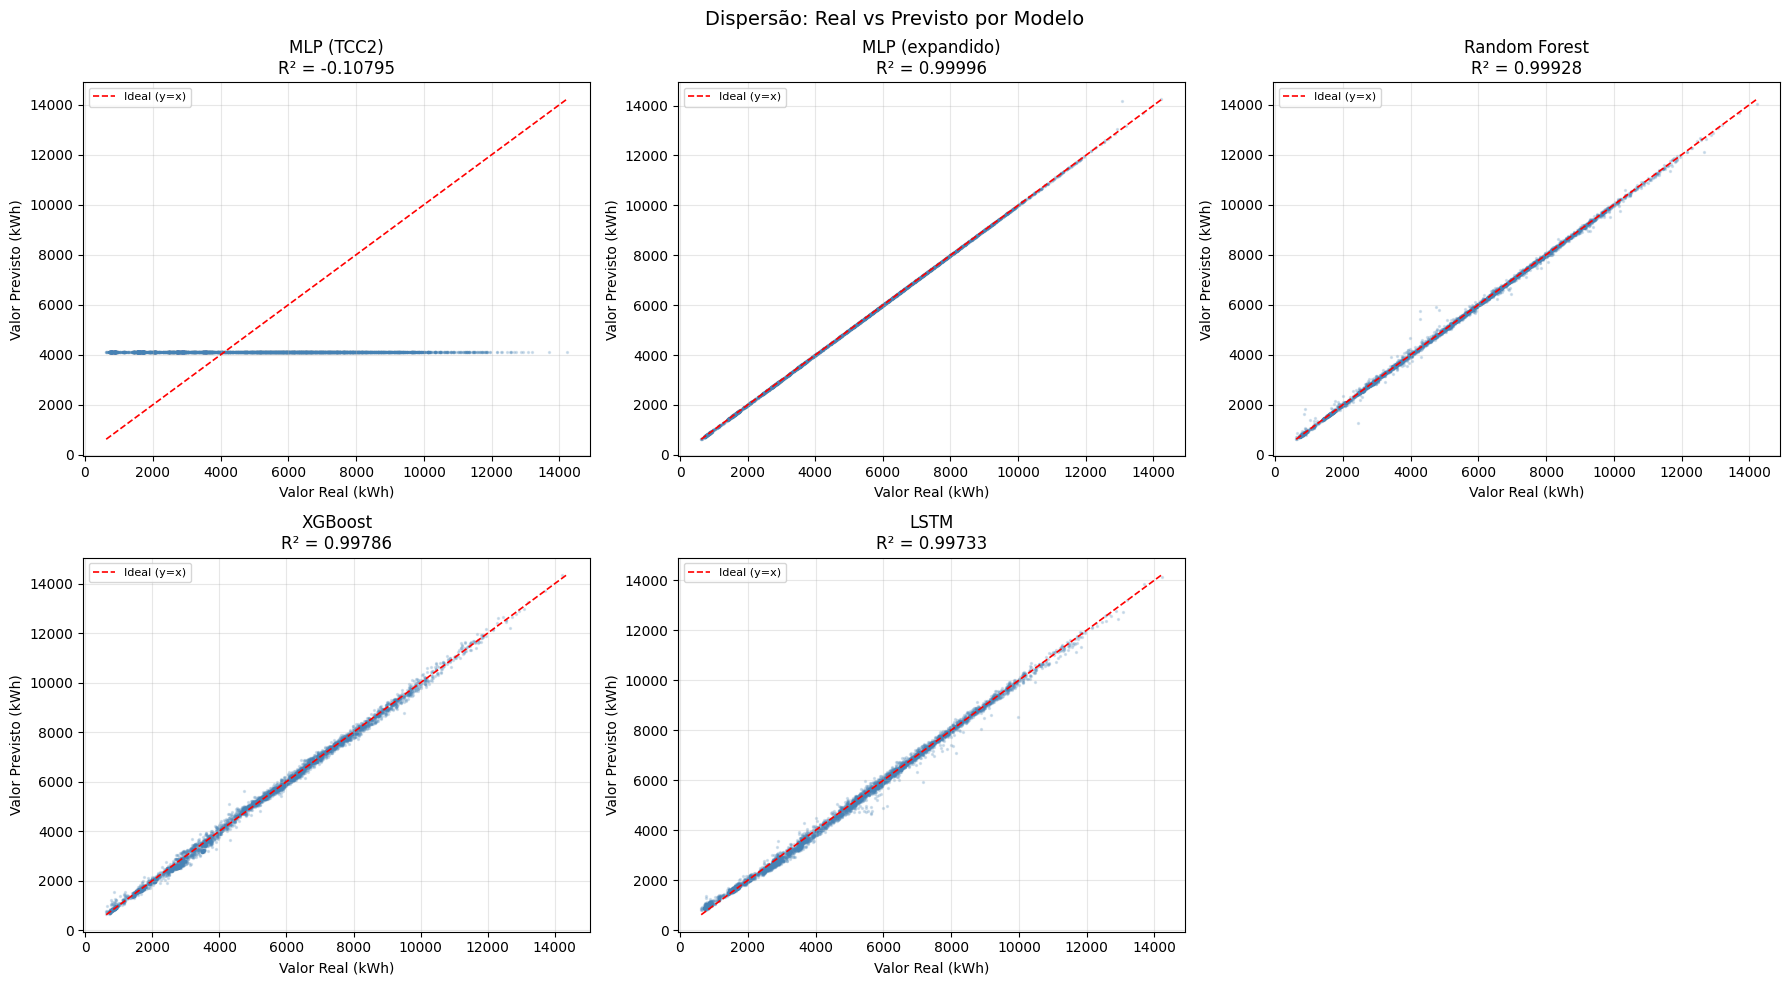

In [4]:
pred_cols = [c for c in preds_df.columns if c.startswith('pred_')]
n_models = len(pred_cols)
y_real = preds_df['Value'].values

ncols = min(3, n_models)
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.ravel()

label_map = {
    'pred_mlp_tcc2': 'MLP (TCC2)',
    'pred_mlp_new':  'MLP (expandido)',
    'pred_rf':       'Random Forest',
    'pred_xgb':      'XGBoost',
    'pred_lstm':     'LSTM',
}

for i, col in enumerate(pred_cols):
    y_pred = preds_df[col].values
    r2 = r2_score(y_real, y_pred)
    label = label_map.get(col, col)

    axes[i].scatter(y_real, y_pred, alpha=0.2, s=2, color='steelblue')
    lim = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    axes[i].plot(lim, lim, 'r--', linewidth=1.2, label='Ideal (y=x)')
    axes[i].set_title(f'{label}\nR² = {r2:.5f}')
    axes[i].set_xlabel('Valor Real (kWh)')
    axes[i].set_ylabel('Valor Previsto (kWh)')
    axes[i].legend(fontsize=8)

# Oculta subplots extras
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Dispersão: Real vs Previsto por Modelo', fontsize=14)
plt.tight_layout()
plt.show()

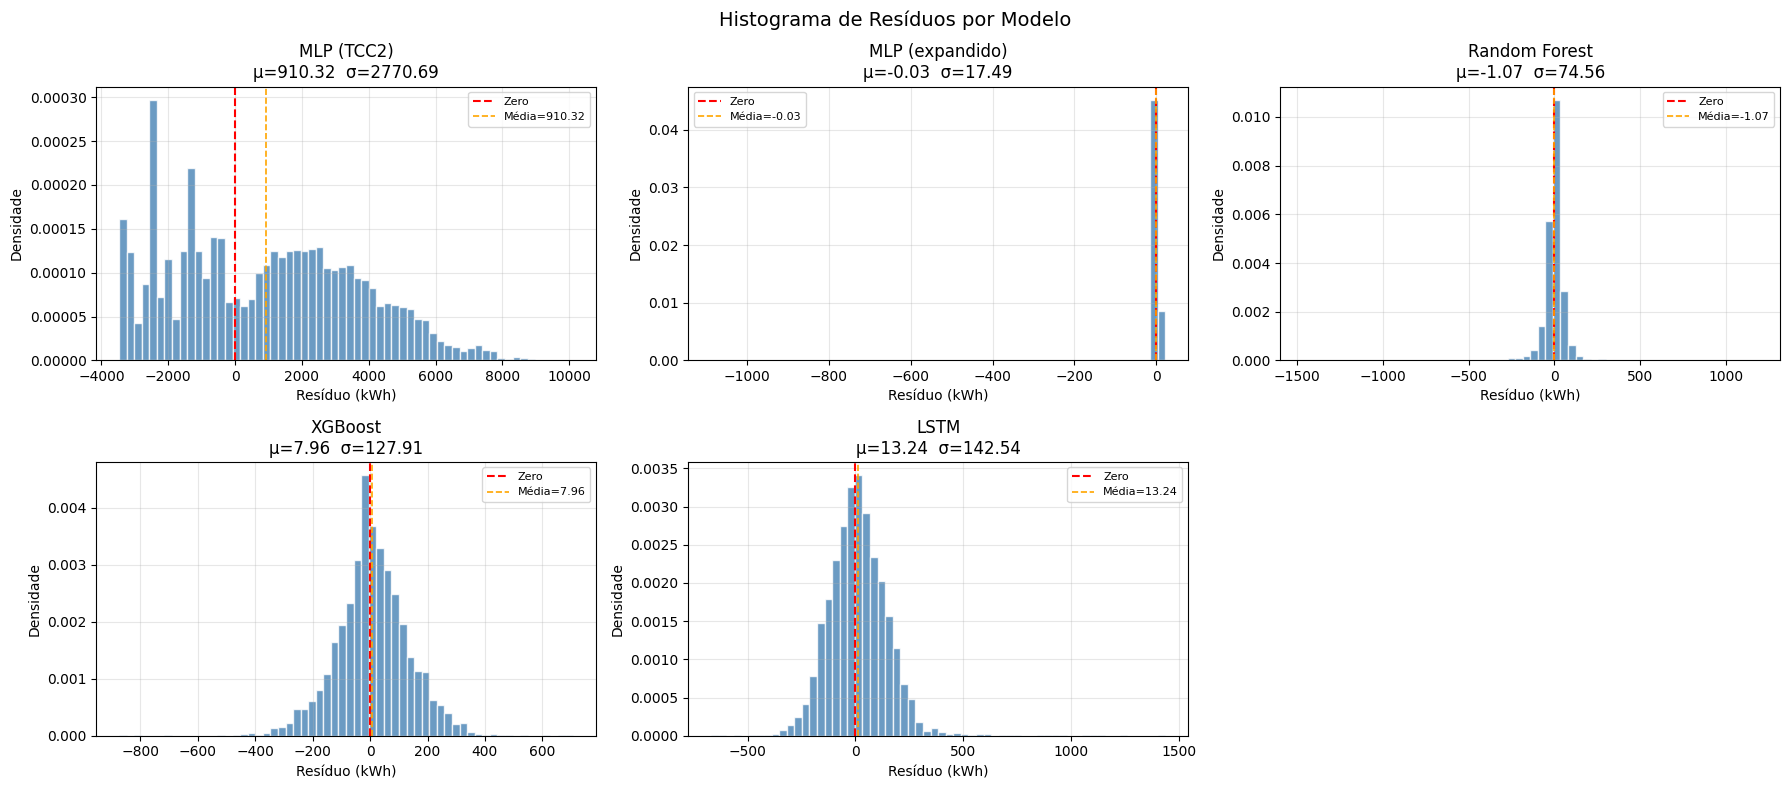

In [5]:
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.ravel()

for i, col in enumerate(pred_cols):
    residuals = y_real - preds_df[col].values
    label = label_map.get(col, col)
    mean_r = residuals.mean()
    std_r  = residuals.std()

    axes[i].hist(residuals, bins=60, color='steelblue', edgecolor='white', density=True, alpha=0.8)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
    axes[i].axvline(mean_r, color='orange', linestyle='--', linewidth=1.2, label=f'Média={mean_r:.2f}')
    axes[i].set_title(f'{label}\nμ={mean_r:.2f}  σ={std_r:.2f}')
    axes[i].set_xlabel('Resíduo (kWh)')
    axes[i].set_ylabel('Densidade')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograma de Resíduos por Modelo', fontsize=14)
plt.tight_layout()
plt.show()

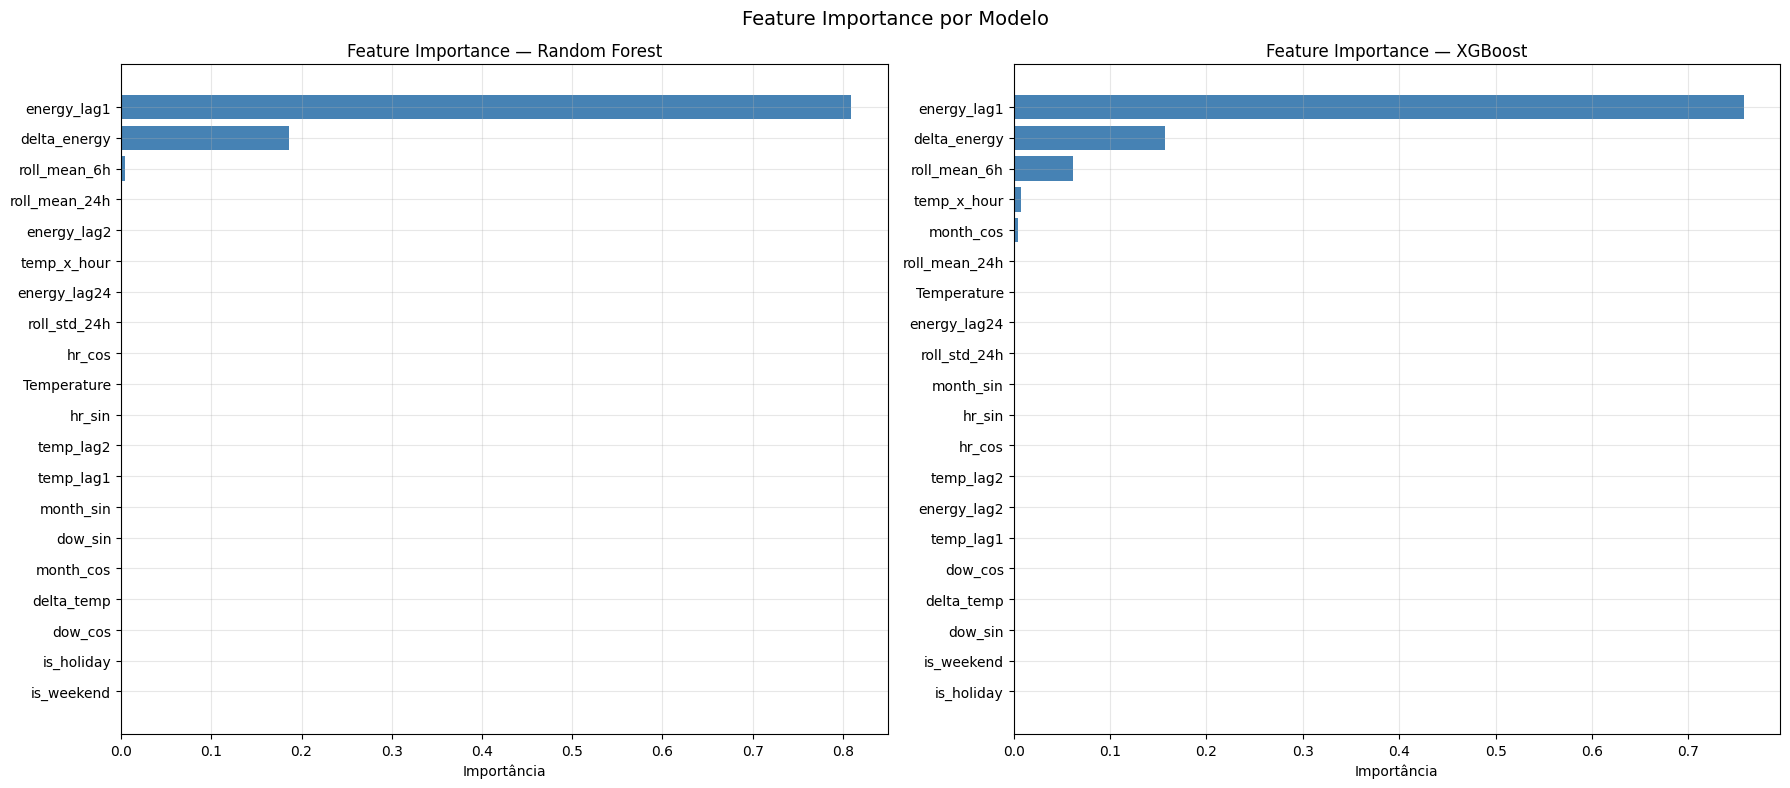

In [6]:
import os

fi_files = {
    'Random Forest': PROC + 'feature_importance_rf.csv',
    'XGBoost':       PROC + 'feature_importance_xgb.csv',
}
available_fi = {name: path for name, path in fi_files.items() if os.path.exists(path)}

if available_fi:
    fig, axes = plt.subplots(1, len(available_fi), figsize=(9*len(available_fi), 8))
    if len(available_fi) == 1:
        axes = [axes]

    for ax, (model_name, path) in zip(axes, available_fi.items()):
        fi = pd.read_csv(path, index_col=0, header=0)
        fi.columns = ['importance']
        fi = fi.sort_values('importance', ascending=True)
        colors = ['steelblue' if v > fi['importance'].median() else 'lightsteelblue'
                  for v in fi['importance']]
        ax.barh(fi.index, fi['importance'], color=colors)
        ax.set_title(f'Feature Importance — {model_name}')
        ax.set_xlabel('Importância')

    plt.suptitle('Feature Importance por Modelo', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Arquivos de feature importance não encontrados. Execute o notebook 04 primeiro.')

In [7]:
try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP {shap.__version__} disponível')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP não instalado — instale com: pip install shap')

SHAP 0.52.0 disponível


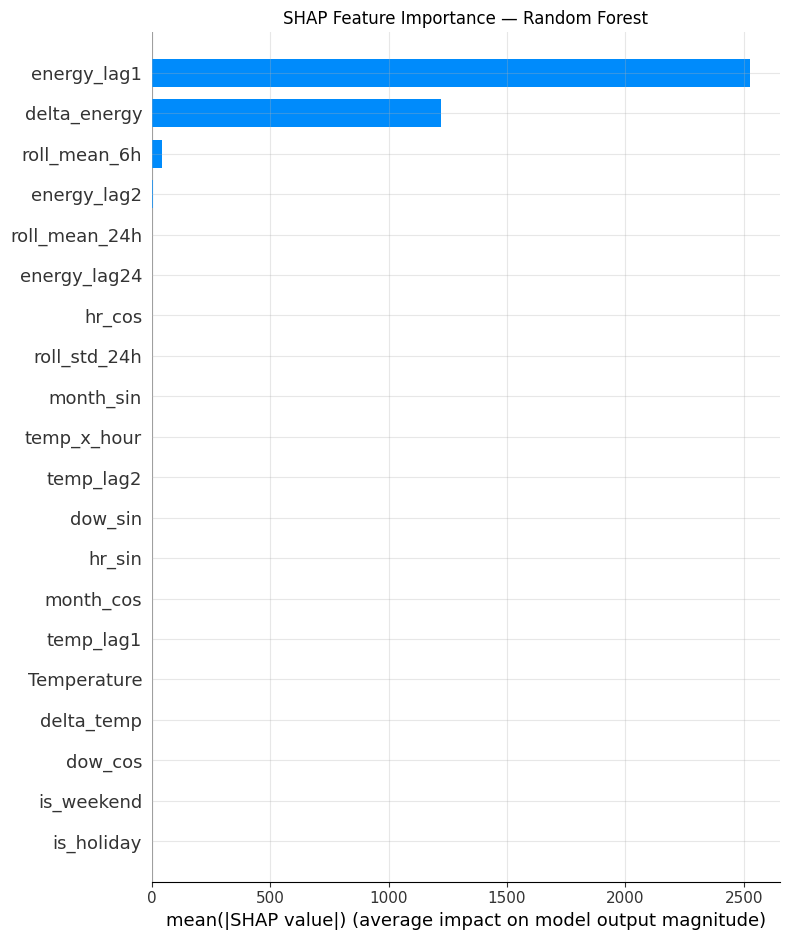

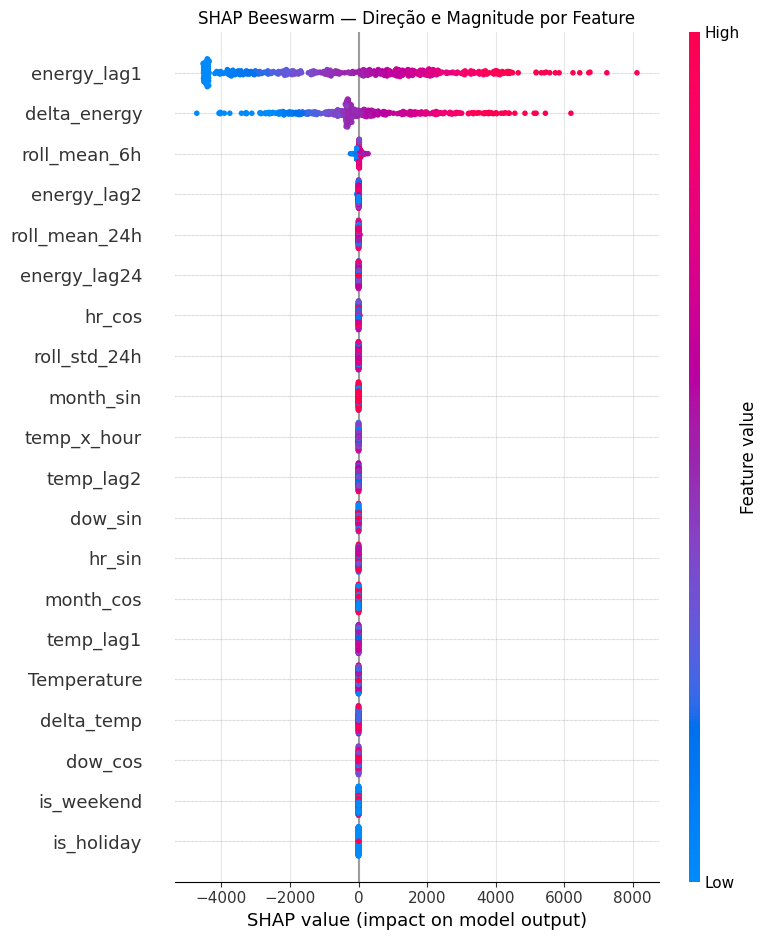

In [8]:
if SHAP_AVAILABLE:
    # Recarrega o modelo RF (precisa ser retreinado se o notebook 04 não está na memória)
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.pipeline import Pipeline

    df_feat = pd.read_csv(PROC + 'df_features.csv', parse_dates=['Timestamp'])
    df_feat = df_feat.sort_values('Timestamp').reset_index(drop=True)

    FEATURES_FULL = [
        'Temperature', 'temp_lag1', 'temp_lag2',
        'energy_lag1', 'energy_lag2', 'energy_lag24',
        'hr_sin', 'hr_cos',
        'dow_sin', 'dow_cos',
        'month_sin', 'month_cos',
        'roll_mean_6h', 'roll_mean_24h', 'roll_std_24h',
        'delta_temp', 'delta_energy', 'temp_x_hour',
        'is_weekend', 'is_holiday',
    ]

    split_idx = int(len(df_feat) * 0.75)
    X_train = df_feat.iloc[:split_idx][FEATURES_FULL].values
    X_test  = df_feat.iloc[split_idx:][FEATURES_FULL].values
    y_train = df_feat.iloc[:split_idx]['Value'].values

    # Treina RF simples para SHAP
    rf_shap = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_shap.fit(X_train, y_train)

    # SHAP TreeExplainer (eficiente para RF)
    explainer = shap.TreeExplainer(rf_shap)
    X_test_sample = X_test[:500]  # amostra para velocidade
    shap_values = explainer.shap_values(X_test_sample)

    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, feature_names=FEATURES_FULL,
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — Random Forest')
    plt.tight_layout()
    plt.show()

    # Beeswarm plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, feature_names=FEATURES_FULL, show=False)
    plt.title('SHAP Beeswarm — Direção e Magnitude por Feature')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP não disponível — instale com: pip install shap')

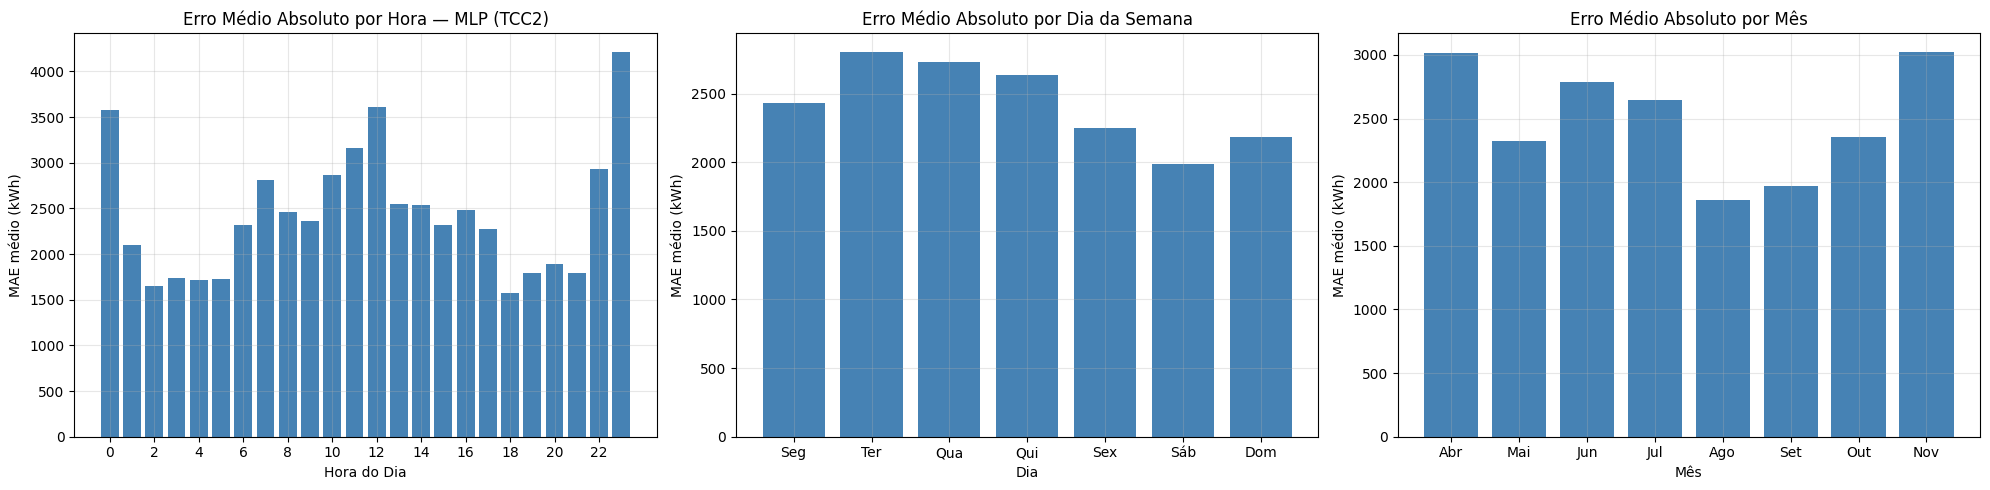

Horas com maior erro:
hour
23    4211.846910
12    3607.319886
0     3576.219279
11    3163.853827
22    2931.155977


In [9]:
# Usa o melhor modelo disponível
best_col = pred_cols[0] if pred_cols else None

if best_col:
    preds_df['residual'] = preds_df['Value'] - preds_df[best_col]
    preds_df['abs_error'] = preds_df['residual'].abs()
    preds_df['hour']      = preds_df['Timestamp'].dt.hour
    preds_df['dayofweek'] = preds_df['Timestamp'].dt.dayofweek
    preds_df['month']     = preds_df['Timestamp'].dt.month

    day_names   = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
    month_names = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Por hora
    err_hour = preds_df.groupby('hour')['abs_error'].mean()
    axes[0].bar(err_hour.index, err_hour.values, color='steelblue')
    axes[0].set_title(f'Erro Médio Absoluto por Hora — {label_map.get(best_col, best_col)}')
    axes[0].set_xlabel('Hora do Dia')
    axes[0].set_ylabel('MAE médio (kWh)')
    axes[0].set_xticks(range(0, 24, 2))

    # Por dia da semana
    err_dow = preds_df.groupby('dayofweek')['abs_error'].mean()
    axes[1].bar(range(len(err_dow)), err_dow.values, color='steelblue',
                tick_label=[day_names[d] for d in err_dow.index])
    axes[1].set_title('Erro Médio Absoluto por Dia da Semana')
    axes[1].set_xlabel('Dia')
    axes[1].set_ylabel('MAE médio (kWh)')

    # Por mês
    err_month = preds_df.groupby('month')['abs_error'].mean()
    axes[2].bar(range(len(err_month)), err_month.values, color='steelblue',
                tick_label=[month_names[m-1] for m in err_month.index])
    axes[2].set_title('Erro Médio Absoluto por Mês')
    axes[2].set_xlabel('Mês')
    axes[2].set_ylabel('MAE médio (kWh)')

    plt.tight_layout()
    plt.show()

    print('Horas com maior erro:')
    print(err_hour.sort_values(ascending=False).head(5).to_string())

In [12]:
print('=== RESULTADOS FINAIS CONSOLIDADOS ===')
print('(Ordenados por R², decrescente)\n')

# Destaque: melhor e pior modelo
best_model = all_results.iloc[0]
worst_model = all_results.iloc[-1]

display(all_results.style
    .highlight_max(subset=['R²'], color='#d4edda')
    .highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)'], color='#d4edda')
    .format({'R²': '{:.5f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE (%)': '{:.3f}'})
)

print(f'\nMelhor modelo : {best_model["Modelo"]} (R²={best_model["R²"]:.5f})')
print(f'Pior modelo   : {worst_model["Modelo"]} (R²={worst_model["R²"]:.5f})')
ganho = ((best_model['R²'] - worst_model['R²']) / abs(worst_model['R²'])) * 100
print(f'Ganho relativo: {ganho:.1f}%')

=== RESULTADOS FINAIS CONSOLIDADOS ===
(Ordenados por R², decrescente)



,Modelo,MAE,RMSE,R²,MAPE (%)
0,MLP (features expandidas),3.3644,17.4877,0.99996,0.099
1,Random Forest,37.4732,74.5665,0.99928,0.988
2,XGBoost,95.8274,128.1559,0.99786,2.606
3,LSTM,104.2571,143.1564,0.99733,3.715
4,Regressão Linear,1083.8078,1499.3586,0.70716,27.487
5,MME (α=0.5),1197.6700,1709.2959,0.61941,29.263
6,MME (α=0.3),1296.0484,1802.9547,0.57656,33.667
7,MME (α=0.1),1519.6861,1996.9895,0.48051,45.349
8,MMS (w=12),1492.1786,2020.4274,0.46825,41.823
9,MMS (w=6),1477.4809,2026.9756,0.46479,38.345



Melhor modelo : MLP (features expandidas) (R²=0.99996)
Pior modelo   : MLP (TCC2 original) (R²=-0.10795)
Ganho relativo: 1026.3%


In [ ]:
# Salva tabela final de resultados
all_results.to_csv(PROC + 'results_final.csv', index=False)
print(f'Tabela final salva: {PROC}results_final.csv')

Tabela final salva: ../data/processed/results_final.csv

Projeto concluído!
Estrutura de notebooks:
  01_eda.ipynb               — Análise Exploratória
  02_feature_engineering.ipynb — Feature Engineering
  03_baseline_models.ipynb   — Modelos Baseline
  04_advanced_models.ipynb   — Modelos Avançados (MLP, RF, XGB, LSTM)
  05_results_comparison.ipynb — Dashboard e Conclusões
  legacy/                    — Notebooks originais do TCC2 (CEFET)
